# Blind PSF Estimator — KernelGAN-Inspired Cross-Scale Approach

**Goal:** Estimate the per-image effective PSF kernel from a single LR lensing image, with no access to simulation metadata, no assumed kernel model, and no ground-truth PSF.

---

### Core Idea: Cross-Scale Patch Recurrence (KernelGAN)

Natural images have a self-similarity property: patches at one scale look statistically similar to patches at a coarser scale. This property is **preserved only when the correct blur kernel is applied**.  

Specifically, if an LR image was formed as:
```
LR = downsample( HR * k_psf ) + noise
```
then:
```
downsample( LR * k_psf )  ≈  downsample( LR )   (in patch statistics)
```

**We exploit this:** Train a deep linear generator G so that `G(LR)` (blur then downsample) produces patches statistically indistinguishable from `bicubic_downsample(LR)`. The optimal G is the true PSF blur.

---

### What is fixed vs. the previous version?

| Problem | Old Code | This Code |
|---------|----------|----------|
| **Cross-scale bug** | Real=LR, Fake=G(LR) at same scale → G learns identity → delta kernel | Real=downsample(LR), Fake=downsample(G(LR)) → proper cross-scale |
| **L_size floor collapse** | Hard floor R_EFF_MIN_PX dominates over GAN signal → always ~0.5" | L_size removed in prototype; GAN signal drives kernel size freely |
| **Moffat FWHM estimation** | Gaussian curve_fit on Moffat → systematic bias, frequent failure | Moment-based FWHM = 2.355 × r_eff: model-agnostic, always defined |
| **Metadata dependency** | Loads simulation_metadata.csv at multiple cells | Zero metadata dependency; HR used only for offline validation |
| **Invalid value checks** | Needed to guard against Gaussian fit failures | Not needed: moment estimator is always valid |

---

### Validation Strategy (no metadata)

Since we have HR images (not used during estimation), we validate via:
1. **Synthetic route (controlled test):** Apply a known PSF to HR → create synthetic LR → run estimator → compare estimated kernel vs known kernel using *normalised cross-correlation*.
2. **Deconvolution sharpness:** Wiener-deconvolve LR with estimated kernel → measure SSIM vs HR. A better kernel estimate → higher SSIM.

Neither HR nor the true kernel enters the GAN training loop.

## Cell 1 — Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path
from scipy.ndimage import gaussian_filter
from scipy.signal import wiener
from skimage.metrics import structural_similarity as ssim
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

PyTorch : 2.5.1
Device  : cuda


## Cell 2 — Configuration

**No metadata CSV.** Only LR and HR image paths are needed.  
HR images are never used during training — only for offline validation.

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
# Point these at your test-task LR/HR pairs (from Task 3A/6A)
# OR at the 3-class simulated dataset (axion/cdm/no_sub) — in either case
# you only need the LR images to RUN the estimator.
LR_DIR  = Path('C:/Users/upraj/Prajwal/GSOC/Pre-GSoC/Unsupervised_SR/Task 2/Dataset 6A/Dataset/LR_sample')        # ← adjust to your path
HR_DIR  = Path('C:/Users/upraj/Prajwal/GSOC/Pre-GSoC/Unsupervised_SR/Task 2/Dataset 6A/Dataset/HR_sample')        # ← used only for validation, not training
OUT_DIR = Path('blind_psf_output')
OUT_DIR.mkdir(exist_ok=True)

# ── Pixel scale ────────────────────────────────────────────────────────────────
# Used only for display (arcsec axis labels). Does not affect estimation.
PIX_LR_ARCSEC = 0.168           # HSC LR pixel scale (arcsec/px)

# ── Generator ─────────────────────────────────────────────────────────────────
# Effective kernel support = (G_KERNEL_SIZE - 1) * G_N_LAYERS + 1 pixels
# 8 layers × 5×5 = 33px support — generous enough for Moffat PSFs up to ~1.5"
G_N_LAYERS    = 8
G_KERNEL_SIZE = 5
G_N_FILTERS   = 32

# ── Discriminator ─────────────────────────────────────────────────────────────
D_PATCH_SIZE = 16               # patch size fed to discriminator (pixels)

# ── Training ──────────────────────────────────────────────────────────────────
N_ITERS      = 2000
LR_G         = 2e-4
LR_D         = 1e-5
N_PATCHES    = 64

# ── Cross-scale ───────────────────────────────────────────────────────────────
# KernelGAN core: compare patches from G(LR) vs patches from downsample(LR, s)
# 0.5 is the classical choice; 0.75 gives a gentler scale step (better for
# small images — if your LR images are 64×64, use 0.75 to avoid tiny patches)
SCALE_FACTOR = 0.5              # downscale factor for cross-scale comparison

# ── Kernel extraction ─────────────────────────────────────────────────────────
KERNEL_SIZE  = 21               # must be odd

# ── Regularisation (PROTOTYPE: only L_neg + L_norm) ──────────────────────────
# L_size and L_shape are full astrophysical priors — excluded from prototype.
# L_neg:  kernel must be non-negative (photon flux is additive)
# L_norm: kernel must sum to 1 (flux conservation)
# Keep these weights small — the GAN signal must dominate, not the prior.
LAMBDA_NEG  = 0.3
LAMBDA_NORM = 1.0

RNG_SEED = 42

print('Configuration loaded.')
print(f'  Generator effective kernel support: {(G_KERNEL_SIZE-1)*G_N_LAYERS+1} px')
print(f'  Cross-scale factor : {SCALE_FACTOR}')
print(f'  Output kernel size : {KERNEL_SIZE}×{KERNEL_SIZE} px'
      f'  ({KERNEL_SIZE * PIX_LR_ARCSEC:.2f}" support at HSC LR scale)')

Configuration loaded.
  Generator effective kernel support: 33 px
  Cross-scale factor : 0.5
  Output kernel size : 21×21 px  (3.53" support at HSC LR scale)


## Cell 3 — Load Images

Only LR images are loaded into the estimator. HR is loaded separately for offline validation.

In [3]:
def load_npy_dir(directory: Path, prefix: str = '') -> dict:
    """Load all .npy files from a directory, keyed by stem."""
    files = sorted(directory.glob(f'{prefix}*.npy'))
    assert len(files) > 0, f'No .npy files found in {directory}'
    return {f.stem: np.load(f).astype(np.float32) for f in files}

lr_images = load_npy_dir(LR_DIR)
hr_images = load_npy_dir(HR_DIR) if HR_DIR.exists() else {}

print(f'Loaded {len(lr_images)} LR images.')
if hr_images:
    print(f'Loaded {len(hr_images)} HR images (for offline validation only).')
else:
    print('No HR directory found — validation will be kernel-only.')

ex_lr = next(iter(lr_images.values()))
print(f'\nLR image: shape={ex_lr.shape}  dtype={ex_lr.dtype}'
      f'  range=[{ex_lr.min():.4f}, {ex_lr.max():.4f}]')

# Safety: if LR images are too small for SCALE_FACTOR=0.5 + patch_size=16,
# the downsampled image must still be >= patch_size in each dimension.
def get_spatial_shape(img):
    """
    Return image spatial shape as (height, width), ignoring an optional channel axis.

    Supports:
    - 2D grayscale:        (H, W)
    - channels-first:      (C, H, W), e.g. (1, 64, 64)
    - channels-last:       (H, W, C), e.g. (64, 64, 1)
    """
    shape = img.shape

    if len(shape) == 2:
        return shape

    if len(shape) == 3:
        # Channels-first case: (C, H, W)
        if shape[0] in (1, 3, 4):
            return shape[1], shape[2]

        # Channels-last case: (H, W, C)
        if shape[2] in (1, 3, 4):
            return shape[0], shape[1]

    raise ValueError(
        f"Unsupported image shape {shape}. Expected (H, W), (C, H, W), or (H, W, C)."
    )


height, width = get_spatial_shape(ex_lr)
min_dim = min(height, width)
min_dim_after_scale = int(min_dim * SCALE_FACTOR)

assert min_dim_after_scale >= D_PATCH_SIZE, (
    f"After downscaling by {SCALE_FACTOR}, smallest spatial dimension is "
    f"{min_dim_after_scale}px from original spatial shape {(height, width)}, "
    f"which is less than patch size {D_PATCH_SIZE}. "
    f"Increase SCALE_FACTOR or reduce D_PATCH_SIZE."
)

print(
    f"\nImage size check: min spatial dim {min_dim}px × {SCALE_FACTOR} "
    f"= {min_dim_after_scale}px >= {D_PATCH_SIZE}px patch size. OK."
)

Loaded 50 LR images.
Loaded 50 HR images (for offline validation only).

LR image: shape=(1, 75, 75)  dtype=float32  range=[0.0045, 0.9734]

Image size check: min spatial dim 75px × 0.5 = 37px >= 16px patch size. OK.


## Cell 4 — Synthetic Degradation Utility

When HR images are available, we can create **controlled synthetic LR images** with a known PSF.  
This lets us test the estimator against a ground-truth kernel — without metadata.

Pipeline: `HR → Gaussian blur (σ_px known) → add noise → bicubic downsample → synthetic LR`

In [4]:
# def make_synthetic_lr(
#     hr_image    : np.ndarray,
#     sigma_px    : float,         # blur sigma IN HR pixels
#     noise_std   : float = 0.02,  # Gaussian noise std (relative to image range)
#     scale_factor: int   = 2,     # spatial downscale factor (e.g. 2 → ×2 LR)
#     rng         : np.random.Generator = None,
# ) -> tuple:
#     """
#     Create a synthetic LR image from HR with a known Gaussian PSF.
#
#     Returns
#     -------
#     lr_synthetic : np.ndarray  — the degraded LR image
#     true_kernel  : np.ndarray  — the ground-truth PSF kernel (KERNEL_SIZE × KERNEL_SIZE),
#                                  normalised to sum=1, in LR pixel coordinates
#     """
#     if rng is None:
#         rng = np.random.default_rng(RNG_SEED)
#
#     # ── Step 1: Gaussian blur in HR space ──────────────────────────────────────
#     hr_blurred = gaussian_filter(hr_image, sigma=sigma_px)
#
#     # ── Step 2: Add noise ─────────────────────────────────────────────────────
#     img_range  = hr_blurred.max() - hr_blurred.min() + 1e-8
#     noise      = rng.normal(0, noise_std * img_range, hr_blurred.shape).astype(np.float32)
#     hr_noisy   = hr_blurred + noise
#
#     # ── Step 3: Bicubic downsample ────────────────────────────────────────────
#     # Use PyTorch for bicubic to stay consistent with training
#     t = torch.from_numpy(hr_noisy[np.newaxis, np.newaxis])   # (1,1,H,W)
#     lr_t = F.interpolate(t, scale_factor=1.0/scale_factor,
#                          mode='bicubic', align_corners=False, antialias=True)
#     lr_synthetic = lr_t[0, 0].numpy()
#
#     # ── Step 4: Build ground-truth kernel in LR pixel coordinates ─────────────
#     # After ×2 downsampling, the PSF sigma in LR pixels = sigma_px / scale_factor
#     sigma_lr = sigma_px / scale_factor
#     n = KERNEL_SIZE
#     yy, xx = np.mgrid[0:n, 0:n]
#     r2 = (xx - n//2)**2 + (yy - n//2)**2
#     true_kernel = np.exp(-r2 / (2 * sigma_lr**2)).astype(np.float32)
#     true_kernel /= true_kernel.sum()   # unit sum
#
#     return lr_synthetic, true_kernel



def _numpy_image_to_nchw(img: np.ndarray):
    """
    Convert a NumPy image to a 4-D torch-compatible NCHW array.

    Supports:
      - 2D grayscale: (H, W)
      - channel-last: (H, W, C)
      - channel-first: (C, H, W)

    Returns
    -------
    img_nchw : np.ndarray
        Image with shape (1, C, H, W)
    layout : str
        Original layout identifier: 'HW', 'HWC', or 'CHW'
    """
    img = np.asarray(img, dtype=np.float32)

    if img.ndim == 2:
        return img[None, None, :, :], "HW"

    if img.ndim == 3:
        # Heuristic: small last dimension usually means HWC, e.g. RGB or bands.
        if img.shape[-1] <= 8:
            img_chw = np.transpose(img, (2, 0, 1))
            return img_chw[None, :, :, :], "HWC"

        # Heuristic: small first dimension usually means CHW.
        if img.shape[0] <= 8:
            return img[None, :, :, :], "CHW"

        raise ValueError(
            f"Ambiguous 3D image shape {img.shape}. Expected HWC with small C last "
            f"or CHW with small C first."
        )

    raise ValueError(
        f"Unsupported image shape {img.shape}. Expected 2D (H, W) or 3D (H, W, C)/(C, H, W)."
    )


def _nchw_to_numpy_image(t: torch.Tensor, layout: str) -> np.ndarray:
    """
    Convert a 4-D tensor with shape (1, C, H, W) back to the original NumPy layout.
    """
    arr = t.detach().cpu().numpy()[0]

    if layout == "HW":
        return arr[0].astype(np.float32)

    if layout == "HWC":
        return np.transpose(arr, (1, 2, 0)).astype(np.float32)

    if layout == "CHW":
        return arr.astype(np.float32)

    raise ValueError(f"Unknown layout: {layout}")


def make_synthetic_lr(
    hr_image,
    sigma_px=2.0,
    noise_std=0.02,
    scale_factor=2,
    rng=None,
):
    """
    Create a synthetic low-resolution image from a high-resolution image.

    Steps:
      1. Gaussian blur the HR image.
      2. Add Gaussian noise.
      3. Bicubic downsample with antialiasing.
      4. Build a Gaussian ground-truth kernel in LR pixel coordinates.

    Supports both grayscale and multi-channel HR images.
    """
    if rng is None:
        rng = np.random.default_rng()

    hr_image = np.asarray(hr_image, dtype=np.float32)

    if scale_factor <= 0:
        raise ValueError(f"scale_factor must be positive, got {scale_factor}")

    # ── Step 1: Gaussian blur ────────────────────────────────────────────────
    # Do not blur across channels. Only blur spatial axes.
    if hr_image.ndim == 2:
        hr_blur = gaussian_filter(hr_image, sigma=sigma_px)
    elif hr_image.ndim == 3:
        if hr_image.shape[-1] <= 8:
            # HWC: blur H and W, not C
            hr_blur = gaussian_filter(hr_image, sigma=(sigma_px, sigma_px, 0))
        elif hr_image.shape[0] <= 8:
            # CHW: blur H and W, not C
            hr_blur = gaussian_filter(hr_image, sigma=(0, sigma_px, sigma_px))
        else:
            raise ValueError(
                f"Ambiguous 3D image shape {hr_image.shape}. Expected HWC or CHW."
            )
    else:
        raise ValueError(
            f"Unsupported HR image shape {hr_image.shape}. Expected 2D or 3D image."
        )

    # ── Step 2: Add Gaussian noise ───────────────────────────────────────────
    noise = rng.normal(loc=0.0, scale=noise_std, size=hr_blur.shape).astype(np.float32)
    hr_noisy = (hr_blur + noise).astype(np.float32)

    # ── Step 3: Bicubic downsample ───────────────────────────────────────────
    # PyTorch interpolate requires 4D input: (N, C, H, W)
    hr_nchw, layout = _numpy_image_to_nchw(hr_noisy)
    t = torch.from_numpy(hr_nchw)

    lr_t = F.interpolate(
        t,
        scale_factor=1.0 / scale_factor,
        mode="bicubic",
        align_corners=False,
        antialias=True,
    )

    lr_synthetic = _nchw_to_numpy_image(lr_t, layout)

    # Optional: avoid tiny bicubic overshoot if your images are normalized.
    # Comment this out if negative values are physically meaningful in your data.
    # lr_synthetic = np.clip(lr_synthetic, 0.0, 1.0)

    # ── Step 4: Build ground-truth kernel in LR pixel coordinates ────────────
    sigma_lr = sigma_px / scale_factor

    kernel_size = int(np.ceil(sigma_lr * 8))
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel_size = max(kernel_size, 5)

    yy, xx = np.mgrid[0:kernel_size, 0:kernel_size]
    cy = cx = kernel_size // 2

    r2 = (xx - cx) ** 2 + (yy - cy) ** 2
    kernel = np.exp(-0.5 * r2 / (sigma_lr ** 2))
    kernel = kernel / kernel.sum()
    kernel = kernel.astype(np.float32)

    return lr_synthetic.astype(np.float32), kernel


def build_ground_truth_kernel(sigma_lr_px: float, kernel_size: int = KERNEL_SIZE) -> np.ndarray:
    """Build a Gaussian ground-truth kernel in LR pixel coordinates."""
    n = kernel_size
    yy, xx = np.mgrid[0:n, 0:n]
    r2 = (xx - n//2)**2 + (yy - n//2)**2
    k = np.exp(-r2 / (2 * sigma_lr_px**2)).astype(np.float32)
    return k / k.sum()


# ── Quick sanity check ─────────────────────────────────────────────────────────
if hr_images:
    ex_hr  = next(iter(hr_images.values()))
    syn_lr, syn_k = make_synthetic_lr(ex_hr, sigma_px=2.0, noise_std=0.02, scale_factor=2)
    print(f'Synthetic LR shape : {syn_lr.shape}  (from HR {ex_hr.shape})')
    print(f'Ground-truth kernel: sum={syn_k.sum():.4f}, max={syn_k.max():.4f}, '
          f'shape={syn_k.shape}')
else:
    print('No HR images — skipping synthetic degradation check.')
    print('The estimator will still run on LR images; kernel validation will use'
          ' cross-correlation between repeated runs instead.')

Synthetic LR shape : (1, 75, 75)  (from HR (1, 150, 150))
Ground-truth kernel: sum=1.0000, max=0.1592, shape=(9, 9)


## Cell 5 — Generator: Deep Linear Network

A PSF is a linear convolution. A stack of linear convolutions (no activations) is also a single linear convolution:  
`k_eff = k_1 ⊛ k_2 ⊛ ... ⊛ k_n`

The effective kernel is extracted by passing a delta impulse through the network — the output IS the kernel.

In [5]:
# class DeepLinearGenerator(nn.Module):
#     """
#     Deep linear convolutional network for blind PSF estimation.
#     No nonlinear activations — guarantees learned transform is a linear convolution.
#
#     Architecture:
#         Conv(1→C) → Conv(C→C) × (n_layers-2) → Conv(C→1)
#         NO activation anywhere.
#
#     Impulse response = effective kernel = estimated PSF.
#     """
#
#     def __init__(self, n_layers=G_N_LAYERS, kernel_size=G_KERNEL_SIZE, n_filters=G_N_FILTERS):
#         super().__init__()
#         assert n_layers >= 2 and kernel_size % 2 == 1
#         pad = kernel_size // 2   # 'same' padding — output same size as input
#
#         layers = []
#         for i in range(n_layers):
#             c_in  = 1        if i == 0            else n_filters
#             c_out = 1        if i == n_layers - 1 else n_filters
#             layers.append(nn.Conv2d(c_in, c_out, kernel_size, padding=pad, bias=False))
#             # !! NO activation — deliberately linear !!
#
#         self.layers = nn.Sequential(*layers)
#         self._init_weights()
#
#     def _init_weights(self):
#         """
#         Initialise each layer as a slightly-spread Gaussian so the
#         composed effective kernel starts as a small-but-nonzero Gaussian,
#         NOT a delta. This prevents early-training collapse before the GAN
#         signal has time to shape the kernel.
#
#         σ = 1.0 px per layer gives a composed σ ≈ sqrt(n_layers) × 1.0 at init.
#         For 8 layers: σ_eff ≈ 2.8 px ≈ 0.47" — a reasonable starting blur.
#         """
#         for m in self.modules():
#             if isinstance(m, nn.Conv2d):
#                 with torch.no_grad():
#                     k  = m.kernel_size[0]
#                     c  = k // 2
#                     sigma = 1.0    # per-layer init sigma in pixels
#                     y, x = torch.meshgrid(
#                         torch.arange(k, dtype=torch.float32),
#                         torch.arange(k, dtype=torch.float32), indexing='ij'
#                     )
#                     gauss = torch.exp(-((x-c)**2 + (y-c)**2) / (2*sigma**2))
#                     gauss /= gauss.sum()
#                     m.weight.data = gauss.unsqueeze(0).unsqueeze(0).expand_as(m.weight.data).clone()
#                     m.weight.data += torch.randn_like(m.weight.data) * 1e-4  # symmetry breaking
#
#     def forward(self, x):
#         return self.layers(x)
#
#     @torch.no_grad()
#     def extract_kernel(self, out_size: int = KERNEL_SIZE) -> np.ndarray:
#         """
#         Extract effective kernel via impulse response.
#         Impulse is placed on a large canvas so boundary effects cannot
#         reach the centre.
#         """
#         self.eval()
#         pad      = out_size * 3
#         sz       = 2 * pad + 1
#         impulse  = torch.zeros(1, 1, sz, sz, device=DEVICE)
#         impulse[0, 0, sz//2, sz//2] = 1.0
#         response = self(impulse)[0, 0].cpu().numpy()
#
#         # Centre-crop around peak
#         cy, cx = np.unravel_index(np.abs(response).argmax(), response.shape)
#         half   = out_size // 2
#         y0, y1 = cy - half, cy + half + 1
#         x0, x1 = cx - half, cx + half + 1
#         # Fallback to geometric centre if peak drifts to boundary
#         if y0 < 0 or y1 > response.shape[0] or x0 < 0 or x1 > response.shape[1]:
#             cy, cx = sz//2, sz//2
#             y0, y1 = cy - half, cy + half + 1
#             x0, x1 = cx - half, cx + half + 1
#         return response[y0:y1, x0:x1].astype(np.float32)


class DeepLinearGenerator(nn.Module):
    """
    Deep linear convolutional network for blind PSF estimation.

    No nonlinear activations: the network remains a single linear convolution.
    The effective PSF is extracted by impulse response.
    """

    def __init__(self, n_layers=G_N_LAYERS, kernel_size=G_KERNEL_SIZE, n_filters=G_N_FILTERS):
        super().__init__()
        assert n_layers >= 2 and kernel_size % 2 == 1

        pad = kernel_size // 2
        layers = []
        for i in range(n_layers):
            cin = 1 if i == 0 else n_filters
            cout = 1 if i == n_layers - 1 else n_filters
            layers.append(nn.Conv2d(cin, cout, kernel_size, padding=pad, bias=False))

        self.layers = nn.Sequential(*layers)
        self.init_weights()

    def init_weights(self):
        """
        Initialize each conv as a near-identity blur with controlled DC gain.

        Key fix:
        If the same unit-sum Gaussian is copied into every (out,in) filter,
        then each output channel sums over cin inputs and gains a factor cin.
        Repeating that through many 32-channel layers makes the effective kernel
        sum explode (~32^(nlayers-1)).

        So for each layer we make the TOTAL kernel feeding each output channel
        sum to ~1 by dividing the base kernel by cin before repeating.
        """
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                with torch.no_grad():
                    cout, cin, k, _ = m.weight.shape
                    c = k // 2
                    sigma = 0.6

                    y, x = torch.meshgrid(
                        torch.arange(k, dtype=torch.float32),
                        torch.arange(k, dtype=torch.float32),
                        indexing="ij"
                    )
                    r2 = (x - c) ** 2 + (y - c) ** 2
                    base = torch.exp(-0.5 * r2 / (sigma ** 2))
                    base = base / base.sum()

                    # Critical fix: divide by cin so each output channel sees
                    # total mass ~1, not cin.
                    w = base.view(1, 1, k, k).repeat(cout, cin, 1, 1) / float(cin)

                    # Tiny noise for symmetry breaking.
                    w = w + 1e-4 * torch.randn_like(w)
                    m.weight.copy_(w)

    def forward(self, x):
        return self.layers(x)

    @torch.no_grad()
    def extract_kernel(self, outsize=KERNEL_SIZE, normalise=True, nonnegative=False):
        """
        Extract effective kernel via impulse response.

        normalise=True is recommended for diagnostics/evaluation.
        nonnegative=False keeps raw learned kernel visible.
        """
        self.eval()
        pad = outsize * 3
        sz = 2 * pad + 1

        impulse = torch.zeros(1, 1, sz, sz, device=DEVICE)
        impulse[0, 0, sz // 2, sz // 2] = 1.0

        response = self(impulse)[0, 0].detach().cpu().numpy()

        cy, cx = np.unravel_index(np.abs(response).argmax(), response.shape)
        half = outsize // 2
        y0, y1 = cy - half, cy + half + 1
        x0, x1 = cx - half, cx + half + 1

        if y0 < 0 or y1 > response.shape[0] or x0 < 0 or x1 > response.shape[1]:
            cy, cx = sz // 2, sz // 2
            y0, y1 = cy - half, cy + half + 1
            x0, x1 = cx - half, cx + half + 1

        k = response[y0:y1, x0:x1].astype(np.float32)

        if nonnegative:
            k = np.clip(k, 0.0, None)

        if normalise:
            s = float(k.sum())
            if abs(s) > 1e-12:
                k = k / s

        return k


# # Architecture verification
# g_test  = DeepLinearGenerator().to(DEVICE)
# x_test  = torch.zeros(1, 1, 64, 64, device=DEVICE)
# y_test  = g_test(x_test)
# k_init  = g_test.extract_kernel()
# n_params = sum(p.numel() for p in g_test.parameters())
#
# print(f'Generator : {G_N_LAYERS} layers × {G_KERNEL_SIZE}×{G_KERNEL_SIZE}  ({n_params:,} params)')
# print(f'In/Out    : {x_test.shape} → {y_test.shape}  (same spatial size ✓)')
# print(f'Init kernel: shape={k_init.shape}  sum={k_init.sum():.3f}  max={k_init.max():.4f}')
# print()
#
# # Verify linearity: G(a*x + b*y) == a*G(x) + b*G(y)
# with torch.no_grad():
#     a, b   = 2.3, -0.7
#     xx     = torch.randn(1, 1, 32, 32, device=DEVICE)
#     yy     = torch.randn(1, 1, 32, 32, device=DEVICE)
#     lhs    = g_test(a*xx + b*yy)
#     rhs    = a*g_test(xx) + b*g_test(yy)
#     max_err = (lhs - rhs).abs().max().item()
# print(f'Linearity check max error: {max_err:.2e}  (should be < 1e-4 ✓)')

gtest = DeepLinearGenerator().to(DEVICE)
xtest = torch.zeros(1, 1, 64, 64, device=DEVICE)
ytest = gtest(xtest)

k_init_raw = gtest.extract_kernel(KERNEL_SIZE, normalise=False, nonnegative=False)
k_init_norm = gtest.extract_kernel(KERNEL_SIZE, normalise=True, nonnegative=True)

n_params = sum(p.numel() for p in gtest.parameters())

print(f"Generator {G_N_LAYERS} layers {G_KERNEL_SIZE}x{G_KERNEL_SIZE} {n_params:,} params")
print(f"In/Out {xtest.shape} -> {ytest.shape}")
print(f"Init RAW kernel sum {k_init_raw.sum():.6f} min {k_init_raw.min():.6e} max {k_init_raw.max():.6e}")
print(f"Init NORM kernel sum {k_init_norm.sum():.6f} min {k_init_norm.min():.6e} max {k_init_norm.max():.6e}")

with torch.no_grad():
    a, b = 2.3, -0.7
    xx = torch.randn(1, 1, 32, 32, device=DEVICE)
    yy = torch.randn(1, 1, 32, 32, device=DEVICE)
    lhs = gtest(a * xx + b * yy)
    rhs = a * gtest(xx) + b * gtest(yy)
    maxerr = (lhs - rhs).abs().max().item()

print(f"Linearity check max error {maxerr:.2e}")

Generator 8 layers 5x5 155,200 params
In/Out torch.Size([1, 1, 64, 64]) -> torch.Size([1, 1, 64, 64])
Init RAW kernel sum 0.995844 min -9.543549e-11 max 5.739778e-02
Init NORM kernel sum 1.000000 min 0.000000e+00 max 5.763732e-02
Linearity check max error 1.47e-04


## Cell 6 — Discriminator: PatchGAN

Classifies small patches as real (from downsampled LR) or fake (from G(LR) then downsampled).  
Spectral normalisation on all conv layers for training stability.

In [6]:
class PatchDiscriminator(nn.Module):
    """3-layer PatchGAN. Outputs a real/fake logit per batch item."""

    def __init__(self, patch_size: int = D_PATCH_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64,  3, padding=1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 64, 3, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 3, padding=1, bias=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        # Spectral norm on all conv layers
        for m in self.net.modules():
            if isinstance(m, nn.Conv2d):
                nn.utils.spectral_norm(m)

    def forward(self, x):
        return self.net(x)


d_test   = PatchDiscriminator().to(DEVICE)
p_test   = torch.zeros(4, 1, D_PATCH_SIZE, D_PATCH_SIZE, device=DEVICE)
s_test   = d_test(p_test)
d_params = sum(p.numel() for p in d_test.parameters())
print(f'Discriminator : PatchGAN  ({d_params:,} params)')
print(f'Input  : {p_test.shape}  →  Output : {s_test.shape}')

Discriminator : PatchGAN  (112,385 params)
Input  : torch.Size([4, 1, 16, 16])  →  Output : torch.Size([4, 1])


## Cell 7 — Physical Regularisation (Prototype: L_neg + L_norm only)

Only two minimal physical constraints:
- **L_neg**: PSF values must be non-negative (photons only add, never subtract).
- **L_norm**: PSF must sum to 1 (flux conservation).

L_shape and L_size (ellipticity + size priors) are excluded from this prototype — their inclusion with
wrong weights is what caused the previous collapse. They will be added in the full implementation.

In [7]:
def psf_regularisation_loss(
    kernel: torch.Tensor,
    lambda_neg : float = LAMBDA_NEG,
    lambda_norm: float = LAMBDA_NORM,
) -> dict:
    """
    Prototype regularisation: only non-negativity and flux conservation.
    Both act as soft constraints — the GAN signal (cross-scale match) should
    dominate kernel shape; these only prevent physically absurd solutions.
    """
    # Non-negativity: penalise any negative values
    L_neg  = torch.abs(torch.clamp(kernel, max=0.0)).sum()

    # Flux conservation: kernel must sum to 1
    L_norm = (kernel.sum() - 1.0) ** 2

    L_reg  = lambda_neg * L_neg + lambda_norm * L_norm

    return {
        'L_reg'  : L_reg,
        'L_neg'  : L_neg.item(),
        'L_norm' : L_norm.item(),
    }


# Unit test on a valid kernel (should give near-zero loss)
n = KERNEL_SIZE
yy, xx = np.mgrid[0:n, 0:n]
test_k  = np.exp(-((xx - n//2)**2 + (yy - n//2)**2) / (2 * 2.0**2)).astype(np.float32)
test_k /= test_k.sum()
reg_test = psf_regularisation_loss(torch.from_numpy(test_k).to(DEVICE))
print('Regularisation unit test on valid Gaussian kernel:')
print(f'  L_neg  = {reg_test["L_neg"]:.2e}  (should be ~0)')
print(f'  L_norm = {reg_test["L_norm"]:.2e}  (should be ~0)')
print(f'  L_reg  = {reg_test["L_reg"].item():.2e}  (should be ~0)')

Regularisation unit test on valid Gaussian kernel:
  L_neg  = 0.00e+00  (should be ~0)
  L_norm = 0.00e+00  (should be ~0)
  L_reg  = 0.00e+00  (should be ~0)


## Cell 8 — Utilities: Patch Extraction, FWHM, Kernel Correlation

**FWHM estimation is moment-based** — no Gaussian or Moffat fitting.  
FWHM = 2.355 × r_eff = 2.355 × √(Q_xx + Q_yy)  
This is always defined, model-agnostic, and gives the same result as Gaussian sigma for Gaussian PSFs.

**Kernel correlation** is the primary validation metric when no metadata is available.

In [8]:
# def image_to_tensor(img_np: np.ndarray, device=DEVICE) -> torch.Tensor:
#     return torch.from_numpy(img_np[np.newaxis, np.newaxis]).to(device)


def image_to_tensor(img_np: np.ndarray, device=DEVICE) -> torch.Tensor:
    """
    Convert an image-like NumPy array to a 4D PyTorch tensor with shape:
        (N, C, H, W) = (1, 1, H, W)

    Accepts common image shapes:
        (H, W)
        (1, H, W)
        (H, W, 1)
        (1, 1, H, W)

    This prevents accidental 5D tensors such as (1, 1, 1, H, W),
    which break torch.nn.functional.interpolate(..., mode='bicubic').
    """
    arr = np.asarray(img_np, dtype=np.float32)

    # Remove singleton dimensions first: (1, H, W), (H, W, 1), etc. -> (H, W)
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected a single 2D grayscale image after squeezing, "
            f"but got shape {arr.shape} from original shape {np.asarray(img_np).shape}"
        )

    tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(device)

    if tensor.ndim != 4:
        raise RuntimeError(f"Internal error: expected 4D tensor, got {tensor.ndim}D")

    return tensor


def extract_random_patches(
    img_t     : torch.Tensor,   # (1, 1, H, W)
    patch_size: int,
    n_patches : int,
) -> torch.Tensor:              # (N, 1, patch_size, patch_size)
    _, _, H, W = img_t.shape
    assert H >= patch_size and W >= patch_size
    ys = torch.randint(0, H - patch_size + 1, (n_patches,))
    xs = torch.randint(0, W - patch_size + 1, (n_patches,))
    return torch.stack([
        img_t[0, 0, y:y+patch_size, x:x+patch_size].unsqueeze(0)
        for y, x in zip(ys, xs)
    ])


# ── Moment-based FWHM — no Gaussian/Moffat fitting, always valid ──────────────
# def estimate_fwhm_from_kernel(
#     kernel     : np.ndarray,
#     pix_scale  : float = PIX_LR_ARCSEC,
# ) -> dict:
#     """
#     Compute FWHM from second moments of the kernel.
#
#     FWHM = 2.355 × r_eff   where  r_eff = sqrt(Q_xx + Q_yy)
#
#     Q_xx, Q_yy are the 2nd moments weighted by the kernel values.
#     This estimator:
#       - Never requires a model assumption (no Gaussian, no Moffat)
#       - Always converges (no curve_fit, no RuntimeError)
#       - Gives the correct answer for Gaussian PSFs (exact by definition)
#       - Gives a physically meaningful size estimate for Moffat and other shapes
#
#     Returns
#     -------
#     dict: fwhm_px, fwhm_arcsec, r_eff_px, centroid_offset_px
#     """
#     k  = np.clip(kernel, 0, None)     # moments should use non-negative values
#     k  = k / (k.sum() + 1e-12)
#     n  = k.shape[0]
#     yy, xx = np.mgrid[0:n, 0:n].astype(np.float32)
#
#     # Centroid
#     mu_x = (xx * k).sum()
#     mu_y = (yy * k).sum()
#
#     # Second moments
#     Q_xx = ((xx - mu_x)**2 * k).sum()
#     Q_yy = ((yy - mu_y)**2 * k).sum()
#
#     r_eff    = np.sqrt(Q_xx + Q_yy + 1e-12)
#     fwhm_px  = 2.355 * r_eff
#
#     # Centroid offset from geometric centre (tells you if kernel has drifted)
#     cx, cy   = n // 2, n // 2
#     centroid_offset = np.sqrt((mu_x - cx)**2 + (mu_y - cy)**2)
#
#     return {
#         'fwhm_px'           : float(fwhm_px),
#         'fwhm_arcsec'       : float(fwhm_px * pix_scale),
#         'r_eff_px'          : float(r_eff),
#         'centroid_offset_px': float(centroid_offset),
#     }


def estimate_fwhm_from_kernel(kernel: np.ndarray, pix_scale: float = PIX_LR_ARCSEC) -> dict:
    """
    Moment-based Gaussian-equivalent FWHM from a 2D kernel.

    For an isotropic Gaussian:
        Qxx = Qyy = sigma^2
    so
        sigma_eq = sqrt((Qxx + Qyy) / 2)
        FWHM = 2.355 * sigma_eq

    This makes the Gaussian unit test come out correctly.
    """
    k = np.asarray(kernel, dtype=np.float32)
    k = np.nan_to_num(k, nan=0.0, posinf=0.0, neginf=0.0)
    k = np.clip(k, 0.0, None)

    s = float(k.sum())
    if s <= 1e-12:
        return {
            "fwhm_px": 0.0,
            "fwhm_arcsec": 0.0,
            "sigma_eq_px": 0.0,
            "reff_px": 0.0,
            "centroid_offset_px": np.nan,
        }

    k = k / s
    h, w = k.shape
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)

    mux = float((xx * k).sum())
    muy = float((yy * k).sum())

    dx = xx - mux
    dy = yy - muy

    Qxx = float((dx * dx * k).sum())
    Qyy = float((dy * dy * k).sum())
    Qxy = float((dx * dy * k).sum())

    sigma_eq = np.sqrt(max((Qxx + Qyy) / 2.0, 1e-12))
    fwhm_px = 2.355 * sigma_eq

    cx = (w - 1) / 2.0
    cy = (h - 1) / 2.0
    centroid_offset = float(np.sqrt((mux - cx) ** 2 + (muy - cy) ** 2))

    return {
        "fwhm_px": float(fwhm_px),
        "fwhm_arcsec": float(fwhm_px * pix_scale),
        "sigma_eq_px": float(sigma_eq),
        "reff_px": float(np.sqrt(max(Qxx + Qyy, 1e-12))),
        "Qxx": float(Qxx),
        "Qyy": float(Qyy),
        "Qxy": float(Qxy),
        "centroid_offset_px": float(centroid_offset),
    }


# ── Normalised cross-correlation between two kernels ──────────────────────────
# def kernel_correlation(k_est: np.ndarray, k_true: np.ndarray) -> float:
#     """
#     Normalised cross-correlation (NCC) between estimated and true kernels.
#     Range: [-1, 1].  1.0 = perfect match.  > 0.95 = excellent in practice.
#
#     Works even when k_est is not the same kernel model as k_true
#     (e.g., estimated may have minor sidelobes, true is a clean Gaussian).
#     """
#     a = (k_est  - k_est.mean())  / (k_est.std()  + 1e-8)
#     b = (k_true - k_true.mean()) / (k_true.std() + 1e-8)
#     return float(np.mean(a * b))


def _center_crop_or_pad_kernel(kernel: np.ndarray, target_shape: tuple[int, int]) -> np.ndarray:
    """
    Center-crop or zero-pad a 2D kernel to target_shape.

    This keeps the kernel centroid/support aligned for fair PSF comparison.
    """
    kernel = np.asarray(kernel, dtype=np.float32)
    if kernel.ndim != 2:
        raise ValueError(f"Expected a 2D kernel, got shape {kernel.shape}")

    target_h, target_w = target_shape
    src_h, src_w = kernel.shape

    if target_h <= 0 or target_w <= 0:
        raise ValueError(f"Invalid target shape: {target_shape}")

    # First center-crop if the source is larger than the target.
    crop_h = min(src_h, target_h)
    crop_w = min(src_w, target_w)

    src_y0 = (src_h - crop_h) // 2
    src_x0 = (src_w - crop_w) // 2
    cropped = kernel[src_y0:src_y0 + crop_h, src_x0:src_x0 + crop_w]

    # Then center-pad if the source is smaller than the target.
    out = np.zeros(target_shape, dtype=np.float32)
    dst_y0 = (target_h - crop_h) // 2
    dst_x0 = (target_w - crop_w) // 2
    out[dst_y0:dst_y0 + crop_h, dst_x0:dst_x0 + crop_w] = cropped

    return out


def _normalise_kernel_for_metric(kernel: np.ndarray) -> np.ndarray:
    """
    Make a kernel numerically safe for shape-comparison metrics.
    """
    kernel = np.asarray(kernel, dtype=np.float32)

    # Remove NaN/Inf values if any appear during unstable training.
    kernel = np.nan_to_num(kernel, nan=0.0, posinf=0.0, neginf=0.0)

    # PSFs should be non-negative. For evaluation, clipping prevents a few
    # negative training artifacts from dominating the correlation metric.
    kernel = np.clip(kernel, 0.0, None)

    total = float(kernel.sum())
    if total > 1e-12:
        kernel = kernel / total

    return kernel


def kernel_correlation(k_est: np.ndarray, k_true: np.ndarray, match: str = "crop_to_smaller") -> float:
    """
    Compute normalized cross-correlation between two PSF kernels.

    Handles kernels with different sizes, e.g. estimated 21x21 vs true 11x11.

    Parameters
    ----------
    k_est : np.ndarray
        Estimated kernel.
    k_true : np.ndarray
        Ground-truth/reference kernel.
    match : str
        "crop_to_smaller" compares only the overlapping central support.
        "pad_to_larger" pads the smaller kernel to the larger support.

    Returns
    -------
    float
        Normalized cross-correlation in approximately [-1, 1].
    """
    k_est = _normalise_kernel_for_metric(k_est)
    k_true = _normalise_kernel_for_metric(k_true)

    if match == "crop_to_smaller":
        target_shape = (
            min(k_est.shape[0], k_true.shape[0]),
            min(k_est.shape[1], k_true.shape[1]),
        )
    elif match == "pad_to_larger":
        target_shape = (
            max(k_est.shape[0], k_true.shape[0]),
            max(k_est.shape[1], k_true.shape[1]),
        )
    else:
        raise ValueError("match must be either 'crop_to_smaller' or 'pad_to_larger'")

    k_est = _center_crop_or_pad_kernel(k_est, target_shape)
    k_true = _center_crop_or_pad_kernel(k_true, target_shape)

    a_std = float(k_est.std())
    b_std = float(k_true.std())

    if a_std < 1e-12 or b_std < 1e-12:
        return 0.0

    a = (k_est - k_est.mean()) / (a_std + 1e-8)
    b = (k_true - k_true.mean()) / (b_std + 1e-8)

    return float(np.mean(a * b))


# ── FWHM unit test ────────────────────────────────────────────────────────────
# print('Moment-based FWHM unit test (Gaussian kernels):')
# for sigma_px in [1.5, 2.0, 2.5, 3.0]:
#     true_fwhm_px = 2.355 * sigma_px
#     n_k  = KERNEL_SIZE
#     yy_t, xx_t = np.mgrid[0:n_k, 0:n_k]
#     k_t  = np.exp(-((xx_t - n_k//2)**2 + (yy_t - n_k//2)**2) / (2*sigma_px**2)).astype(np.float32)
#     k_t /= k_t.sum()
#     res  = estimate_fwhm_from_kernel(k_t)
#     err  = abs(res['fwhm_px'] - true_fwhm_px)
#     print(f'  sigma={sigma_px:.1f}px  true_FWHM={true_fwhm_px:.2f}px'
#           f'  est_FWHM={res["fwhm_px"]:.2f}px  err={err:.3f}px'
#           f'  NCC={kernel_correlation(k_t, k_t):.4f}')

print("Moment-based FWHM unit test: Gaussian kernels")
for sigma_px in [1.5, 2.0, 2.5, 3.0]:
    true_fwhm_px = 2.355 * sigma_px
    nk = KERNEL_SIZE
    yyt, xxt = np.mgrid[0:nk, 0:nk]
    kt = np.exp(-((xxt - nk // 2) ** 2 + (yyt - nk // 2) ** 2) / (2 * sigma_px ** 2)).astype(np.float32)
    kt /= kt.sum()

    res = estimate_fwhm_from_kernel(kt)
    err = abs(res["fwhm_px"] - true_fwhm_px)

    print(
        f"sigma={sigma_px:.1f}px "
        f"true_FWHM={true_fwhm_px:.3f}px "
        f"est_FWHM={res['fwhm_px']:.3f}px "
        f"err={err:.4f}px"
    )

# FWHM unit test on a Moffat kernel (β=3) — no curve_fit needed
print('\nMoment-based FWHM on Moffat kernels (model-agnostic):')
for fwhm_arcsec in [0.55, 0.70, 0.85]:
    sigma_m = (fwhm_arcsec / PIX_LR_ARCSEC) / 2.355
    n_k = KERNEL_SIZE
    yy_t, xx_t = np.mgrid[0:n_k, 0:n_k]
    r2  = (xx_t - n_k//2)**2 + (yy_t - n_k//2)**2
    k_m = (1 + r2 / sigma_m**2) ** (-3.0)
    k_m = (k_m / k_m.sum()).astype(np.float32)
    res = estimate_fwhm_from_kernel(k_m)
    print(f'  FWHM_true={fwhm_arcsec:.2f}"  FWHM_est={res["fwhm_arcsec"]:.3f}"'
          f'  (moment-based, no fit required)')

Moment-based FWHM unit test: Gaussian kernels
sigma=1.5px true_FWHM=3.532px est_FWHM=3.532px err=0.0000px
sigma=2.0px true_FWHM=4.710px est_FWHM=4.710px err=0.0000px
sigma=2.5px true_FWHM=5.888px est_FWHM=5.886px err=0.0013px
sigma=3.0px true_FWHM=7.065px est_FWHM=7.044px err=0.0207px

Moment-based FWHM on Moffat kernels (model-agnostic):
  FWHM_true=0.55"  FWHM_est=0.379"  (moment-based, no fit required)
  FWHM_true=0.70"  FWHM_est=0.483"  (moment-based, no fit required)
  FWHM_true=0.85"  FWHM_est=0.581"  (moment-based, no fit required)


## Cell 9 — Training Loop (Fixed Cross-Scale Mechanism)

### The Bug in the Previous Version

**Old code:**
```python
real_patches = patches(lr_t)        # LR at scale 1.0
fake_patches = patches(G(lr_t))     # G(LR) also at scale 1.0
```
This trains G to output something that looks like LR itself → G learns identity → delta kernel.

**Fixed code (KernelGAN-correct):**
```python
lr_small     = bicubic_downsample(lr_t, scale=s)   # real cross-scale target
G_lr_small   = bicubic_downsample(G(lr_t), scale=s) # G's prediction of cross-scale
real_patches = patches(lr_small)     # from actual downsampled LR
fake_patches = patches(G_lr_small)   # from G's blurred+downsampled LR
```
D distinguishes these → G learns: what blur makes `blur(LR) ↓_s ≈ LR ↓_s` → G learns PSF.

In [9]:
def train_blind_psf(
    lr_image    : np.ndarray,
    n_iters     : int   = N_ITERS,
    lr_g        : float = LR_G,
    lr_d        : float = LR_D,
    n_patches   : int   = N_PATCHES,
    patch_size  : int   = D_PATCH_SIZE,
    scale_factor: float = SCALE_FACTOR,
    verbose     : bool  = True,
    log_interval: int   = 50,
) -> dict:
    """
    Blind PSF estimation from a single LR image via cross-scale adversarial training.

    No metadata, no ground-truth kernel, no assumed PSF model.

    Algorithm (KernelGAN-correct):
    ─────────────────────────────
    Each iteration:
      1. Compute cross-scale targets:
             lr_small  = bicubic_downsample(LR, scale_factor)    ← real
             gen_small = bicubic_downsample(G(LR), scale_factor) ← fake

      2. D update:  L_D = BCE(D(real_patches), 1) + BCE(D(fake_patches), 0)

      3. G update:  L_G = BCE(D(G_patches), 1) + λ_neg·L_neg + λ_norm·L_norm
                    (physical regularisation via differentiable impulse response)

    Returns
    -------
    dict:
        kernel      : estimated PSF kernel (KERNEL_SIZE × KERNEL_SIZE float32)
        kernel_init : kernel before training (for comparison)
        fwhm_result : moment-based FWHM estimate
        loss_history: list of per-log-interval dicts
        generator   : trained DeepLinearGenerator (for further inspection)
    """
    torch.manual_seed(RNG_SEED)

    G = DeepLinearGenerator().to(DEVICE)
    D = PatchDiscriminator(patch_size).to(DEVICE)

    opt_G  = optim.Adam(G.parameters(), lr=lr_g, betas=(0.9, 0.999))
    opt_D  = optim.Adam(D.parameters(), lr=lr_d, betas=(0.9, 0.999))
    sch_G  = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=n_iters, eta_min=1e-6)
    sch_D  = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=n_iters, eta_min=1e-6)
    bce    = nn.BCEWithLogitsLoss()

    lr_t           = image_to_tensor(lr_image)          # (1,1,H,W)
    # kernel_init    = G.extract_kernel(KERNEL_SIZE)
    kernel_init_raw = G.extract_kernel(KERNEL_SIZE, normalise=False, nonnegative=False)
    kernel_init = G.extract_kernel(KERNEL_SIZE, normalise=True, nonnegative=True)
    loss_history   = []

    # Pre-compute the real cross-scale target (constant across iterations)
    with torch.no_grad():
        lr_small = F.interpolate(
            lr_t, scale_factor=scale_factor,
            mode='bicubic', align_corners=False
        )   # (1, 1, H*s, W*s)

    # Check downsampled size is still large enough for patch extraction
    _, _, Hs, Ws = lr_small.shape
    assert Hs >= patch_size and Ws >= patch_size, (
        f'Downsampled image ({Hs}×{Ws}) is smaller than patch size ({patch_size}). '
        f'Increase SCALE_FACTOR or reduce D_PATCH_SIZE.'
    )

    real_labels = torch.ones( n_patches, 1, device=DEVICE)
    fake_labels = torch.zeros(n_patches, 1, device=DEVICE)

    pbar = tqdm(range(n_iters), desc='Blind PSF', leave=False) if verbose else range(n_iters)

    for iteration in pbar:

        # ──────────────────────────────────────────────────────────────────────
        # Step 1: Discriminator update
        # ──────────────────────────────────────────────────────────────────────
        G.eval()
        D.train()
        opt_D.zero_grad()

        with torch.no_grad():
            gen_out  = G(lr_t)                               # G(LR), same size as LR
            gen_small = F.interpolate(                       # downsample G(LR) → same size as lr_small
                gen_out, scale_factor=scale_factor,
                mode='bicubic', align_corners=False
            )

        # Real = patches from actual downsampled LR
        real_patches = extract_random_patches(lr_small.detach(), patch_size, n_patches)
        # Fake = patches from G(LR) then downsampled
        fake_patches = extract_random_patches(gen_small.detach(), patch_size, n_patches)

        loss_D = bce(D(real_patches), real_labels) + bce(D(fake_patches), fake_labels)
        loss_D.backward()
        opt_D.step()

        # ──────────────────────────────────────────────────────────────────────
        # Step 2: Generator update
        # ──────────────────────────────────────────────────────────────────────
        G.train()
        D.eval()
        opt_G.zero_grad()

        gen_out   = G(lr_t)
        gen_small = F.interpolate(
            gen_out, scale_factor=scale_factor,
            mode='bicubic', align_corners=False
        )
        fake_patches_g = extract_random_patches(gen_small, patch_size, n_patches)
        loss_GAN = bce(D(fake_patches_g), real_labels)     # G wants D to call it real

        # # ── Physical regularisation via differentiable impulse response ───────
        # # We pass a delta impulse through G WITH gradient flow, so backprop
        # # reaches G's weights through the regularisation term.
        # canvas = KERNEL_SIZE * 3
        # impulse = torch.zeros(1, 1, canvas, canvas, device=DEVICE)
        # impulse[0, 0, canvas//2, canvas//2] = 1.0
        # response = G(impulse)
        # half = KERNEL_SIZE // 2
        # c    = canvas // 2
        # kernel_diff = response[0, 0, c-half : c+half+1, c-half : c+half+1]
        #
        # reg_dict = psf_regularisation_loss(kernel_diff)
        # loss_G   = loss_GAN + reg_dict['L_reg']

        # ── Physical regularisation via differentiable impulse response ───────
        # Pass a delta impulse through G WITH gradient flow so backprop
        # reaches G's weights via the regularisation term.
        canvas = KERNEL_SIZE * 3
        impulse = torch.zeros(1, 1, canvas, canvas, device=DEVICE)
        impulse[0, 0, canvas // 2, canvas // 2] = 1.0
        response = G(impulse)   # (1,1,canvas,canvas)

        # Crop the central KERNEL_SIZE region (same as current kernel_diff)
        half = KERNEL_SIZE // 2
        c    = canvas // 2
        kernel_crop = response[0, 0, c-half : c+half+1, c-half : c+half+1]

        # ----- Important change: enforce flux conservation on the FULL impulse response
        # This prevents the network from moving mass outside the cropped region to avoid the penalty.
        response_sum = response.sum()                # differentiable scalar
        L_norm_full = (response_sum - 1.0) ** 2      # global flux penalty

        # Non-negativity penalty can still use the central crop (optional)
        L_neg = torch.abs(torch.clamp(kernel_crop, max=0.0)).sum()

        # Total reg loss: weight the full-norm penalty by lambda_norm, and neg by lambda_neg
        L_reg = LAMBDA_NEG * L_neg + LAMBDA_NORM * L_norm_full

        # For logging, expose scalar values
        reg_dict = {
            'L_reg' : L_reg,
            'L_neg' : float(L_neg.item()),
            'L_norm_full' : float(L_norm_full.item()),
            'kernel_crop_sum' : float(kernel_crop.sum().item()),
            'response_sum' : float(response_sum.item()),
        }

        loss_G = loss_GAN + L_reg

        loss_G.backward()
        # nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
        opt_G.step()
        sch_G.step()
        sch_D.step()

        # ── Logging ───────────────────────────────────────────────────────────
        if verbose and iteration % log_interval == 0:
            # k_np    = G.extract_kernel(KERNEL_SIZE)
            # fwhm_r  = estimate_fwhm_from_kernel(k_np)
            # log_entry = {
            #     'iter'      : iteration,
            #     'loss_D'    : loss_D.item(),
            #     'loss_GAN'  : loss_GAN.item(),
            #     'loss_G'    : loss_G.item(),
            #     'fwhm_px'   : fwhm_r['fwhm_px'],
            #     'fwhm_arcsec': fwhm_r['fwhm_arcsec'],
            #     'centroid_offset': fwhm_r['centroid_offset_px'],
            #     **{k: v for k, v in reg_dict.items() if k != 'L_reg'},
            # }

            # k_np    = G.extract_kernel(KERNEL_SIZE)
            # fwhm_r  = estimate_fwhm_from_kernel(k_np)
            k_np_raw = G.extract_kernel(KERNEL_SIZE, normalise=False, nonnegative=False)
            k_np = G.extract_kernel(KERNEL_SIZE, normalise=True, nonnegative=True)
            fwhm_r = estimate_fwhm_from_kernel(k_np)
            # kernel_np_sum is raw sum of extracted kernel (peak-centered)
            #kernel_np_sum = float(np.nan_to_num(k_np).sum())
            log_entry = {
                'iter'         : iteration,
                'loss_D'       : loss_D.item(),
                'loss_GAN'     : loss_GAN.item(),
                'loss_G'       : loss_G.item(),
                'fwhm_px'      : fwhm_r['fwhm_px'],
                'fwhm_arcsec'  : fwhm_r['fwhm_arcsec'],
                'centroid_offset': fwhm_r['centroid_offset_px'],
                #'kernel_sum_raw': kernel_np_sum,
                "kernel_sum_raw": float(k_np_raw.sum()),
                "kernel_min_raw": float(k_np_raw.min()),
                "kernel_max_raw": float(k_np_raw.max()),
                # include reg debug values from reg_dict
                **{k: v for k, v in reg_dict.items() if k != 'L_reg'},
            }

            loss_history.append(log_entry)
            if verbose:
                pbar.set_postfix({
                    'D'    : f'{loss_D.item():.3f}',
                    'G'    : f'{loss_G.item():.3f}',
                    'FWHM' : f'{fwhm_r["fwhm_arcsec"]:.3f}"',
                    'Δcen' : f'{fwhm_r["centroid_offset_px"]:.2f}px',
                })

    G.eval()
    # kernel_final = G.extract_kernel(KERNEL_SIZE)
    # fwhm_result  = estimate_fwhm_from_kernel(kernel_final)
    kernel_final_raw = G.extract_kernel(KERNEL_SIZE, normalise=False, nonnegative=False)
    kernel_final = G.extract_kernel(KERNEL_SIZE, normalise=True, nonnegative=True)
    fwhm_result = estimate_fwhm_from_kernel(kernel_final)

    return {
        'kernel'      : kernel_final,
        "kernel_raw": kernel_final_raw,
        'kernel_init' : kernel_init,
        "kernel_init_raw": kernel_init_raw,
        'fwhm_result' : fwhm_result,
        'loss_history': loss_history,
        'generator'   : G,
    }


print('train_blind_psf() defined.')

train_blind_psf() defined.


## Cell 10 — Validation: Deconvolution Sharpness vs HR

Since HR images are available, we test the quality of the estimated kernel by:
1. Wiener-deconvolving the LR with the estimated kernel
2. Computing SSIM against the HR image (after matching resolution)

A better kernel estimate → sharper deconvolution → higher SSIM.  
This validates the kernel **indirectly** without needing the true kernel at test time.

We also compare against a fixed Gaussian baseline (σ=1.5px) to show the estimated kernel adds value.

In [10]:
# def wiener_deconvolve(
#     image   : np.ndarray,
#     kernel  : np.ndarray,
#     noise_power: float = 0.01,   # Wiener regularisation (larger = smoother)
# ) -> np.ndarray:
#     """
#     Wiener deconvolution of image using the given PSF kernel.
#     Returns a deblurred image of the same shape.
#
#     noise_power: regularisation strength. Tune to the estimated SNR:
#         - High SNR (clean simulation): 0.001–0.01
#         - Low SNR (real HSC):          0.01–0.05
#     """
#     from scipy.fft import fft2, ifft2, fftshift
#
#     H, W = image.shape
#
#     # Pad kernel to image size, centred
#     psf_padded = np.zeros((H, W), dtype=np.float32)
#     kh, kw = kernel.shape
#     y0 = H//2 - kh//2
#     x0 = W//2 - kw//2
#     psf_padded[y0:y0+kh, x0:x0+kw] = kernel
#
#     # Wiener filter in frequency domain
#     from scipy.fft import ifftshift
#     psf_ft  = fft2(ifftshift(psf_padded))
#     img_ft  = fft2(image)
#     H_conj  = np.conj(psf_ft)
#     wiener_filter = H_conj / (np.abs(psf_ft)**2 + noise_power)
#     deconv  = np.real(ifft2(img_ft * wiener_filter))
#
#     return deconv.astype(np.float32)
#
#
# def compute_deconv_ssim(
#     lr_image    : np.ndarray,
#     hr_image    : np.ndarray,
#     kernel      : np.ndarray,
#     noise_power : float = 0.01,
# ) -> float:
#     """
#     Deconvolve LR with kernel, upsample to HR size, compute SSIM vs HR.
#     Used to validate kernel quality against HR oracle.
#     """
#     # Deconvolve LR
#     deconvolved = wiener_deconvolve(lr_image, kernel, noise_power)
#
#     # Upsample to HR size
#     t_deconv = torch.from_numpy(deconvolved[np.newaxis, np.newaxis])
#     t_up     = F.interpolate(t_deconv, size=hr_image.shape,
#                               mode='bicubic', align_corners=False)
#     deconv_up = t_up[0, 0].numpy()
#
#     # Normalise both to [0, 1] for SSIM
#     def norm01(x):
#         lo, hi = np.percentile(x, 1), np.percentile(x, 99)
#         return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
#
#     val_ssim = ssim(
#         norm01(deconv_up), norm01(hr_image),
#         data_range=1.0
#     )
#     return float(val_ssim)
#
#
# print('Validation utilities defined.')
# print('compute_deconv_ssim(): deconvolve LR → upsample → SSIM vs HR')

In [11]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.fft import fft2, ifft2, ifftshift
from skimage.metrics import structural_similarity as ssim


def as_2d_image(arr, name="image"):
    """
    Convert common grayscale image shapes to a 2D array.

    Accepted shapes:
    - (H, W)
    - (1, H, W)
    - (H, W, 1)
    - (1, 1, H, W)

    Raises a clear error for true batches or multi-channel images.
    """
    arr = np.asarray(arr)

    # Remove singleton dimensions, e.g. (1, H, W) -> (H, W)
    squeezed = np.squeeze(arr)

    if squeezed.ndim != 2:
        raise ValueError(
            f"{name} must represent a single 2D grayscale image. "
            f"Got shape {arr.shape}, which becomes {squeezed.shape} after squeeze(). "
            "If this is a batch or multi-channel image, select one image/channel first."
        )

    return squeezed.astype(np.float32)


def normalize_kernel(kernel, eps=1e-12):
    """
    Ensure the PSF kernel is 2D, finite, non-negative, and sums to 1.
    This is important for stable Wiener deconvolution.
    """
    kernel = as_2d_image(kernel, name="kernel")
    kernel = np.nan_to_num(kernel, nan=0.0, posinf=0.0, neginf=0.0)
    kernel = np.maximum(kernel, 0.0)

    total = float(kernel.sum())
    if total <= eps:
        raise ValueError(
            f"Kernel sum is too small or zero: {total}. "
            "Cannot normalize PSF kernel."
        )

    return (kernel / total).astype(np.float32)


def wiener_deconvolve(image, kernel, noise_power=0.01):
    """
    Wiener deconvolution of a single 2D image using the given PSF kernel.

    Parameters
    ----------
    image : np.ndarray
        Grayscale image. Accepted shapes: (H, W), (1, H, W), (H, W, 1), etc.
    kernel : np.ndarray
        PSF kernel. Will be normalized to sum to 1.
    noise_power : float
        Wiener regularization/noise-to-signal parameter.

    Returns
    -------
    np.ndarray
        Deblurred 2D image with shape (H, W).
    """
    image = as_2d_image(image, name="image")
    kernel = normalize_kernel(kernel)

    H, W = image.shape
    kh, kw = kernel.shape

    if kh > H or kw > W:
        raise ValueError(
            f"Kernel shape {kernel.shape} cannot be larger than image shape {image.shape}."
        )

    # Pad PSF to image size.
    psf_padded = np.zeros((H, W), dtype=np.float32)

    y0 = (H - kh) // 2
    x0 = (W - kw) // 2
    psf_padded[y0:y0 + kh, x0:x0 + kw] = kernel

    # Move PSF center to the origin for FFT convolution/deconvolution.
    psf_padded = ifftshift(psf_padded)

    image_fft = fft2(image)
    kernel_fft = fft2(psf_padded)

    kernel_power = np.abs(kernel_fft) ** 2

    # Wiener filter:
    # X_hat = Y * H* / (|H|^2 + K)
    deconv_fft = image_fft * np.conj(kernel_fft) / (kernel_power + noise_power)

    deconvolved = np.real(ifft2(deconv_fft)).astype(np.float32)

    return deconvolved


def compute_deconv_ssim(lr_image, hr_image, kernel, noise_power=0.01):
    """
    Deconvolve LR with kernel, upsample to HR size, compute SSIM vs HR.

    Handles LR/HR arrays with singleton dimensions safely.
    """
    lr_image = as_2d_image(lr_image, name="lr_image")
    hr_image = as_2d_image(hr_image, name="hr_image")
    kernel = normalize_kernel(kernel)

    # Deconvolve LR.
    deconvolved = wiener_deconvolve(lr_image, kernel, noise_power=noise_power)

    # Upsample deconvolved LR image to HR size.
    t_deconv = torch.from_numpy(deconvolved[None, None].astype(np.float32))

    t_up = F.interpolate(
        t_deconv,
        size=hr_image.shape,
        mode="bilinear",
        align_corners=False,
    )

    upsampled = t_up[0, 0].detach().cpu().numpy().astype(np.float32)

    # Make both images finite.
    upsampled = np.nan_to_num(upsampled, nan=0.0, posinf=0.0, neginf=0.0)
    hr_image = np.nan_to_num(hr_image, nan=0.0, posinf=0.0, neginf=0.0)

    # SSIM requires a valid data_range.
    data_min = float(min(hr_image.min(), upsampled.min()))
    data_max = float(max(hr_image.max(), upsampled.max()))
    data_range = data_max - data_min

    if data_range <= 1e-12:
        raise ValueError(
            "Cannot compute SSIM because both images have near-constant intensity."
        )

    return float(ssim(hr_image, upsampled, data_range=data_range))

## Cell 11 — Run Estimator on Synthetic LR (Controlled Validation)

We create a synthetic LR from the first HR image with a **known** Gaussian PSF.  
This gives us ground truth for kernel comparison via NCC.

Three test sigma values covering the HSC seeing range: 0.5", 0.65", 0.8"

In [12]:
if not hr_images:
    print('No HR images available — skipping synthetic validation.')
    print('Proceed to Cell 12 to run on real LR images.')
else:
    # Use first HR image for synthetic validation
    hr_key = next(iter(hr_images))
    hr_img = hr_images[hr_key]

    test_sigmas_arcsec = [0.50, 0.65, 0.80]   # FWHM range for HSC ground-based seeing
    synthetic_results  = []

    print(f'Synthetic validation on HR image "{hr_key}"  (shape: {hr_img.shape})')
    print(f'Testing {len(test_sigmas_arcsec)} PSF sizes × {N_ITERS} iterations each.')
    print()

    # Baseline: fixed Gaussian kernel (σ=1.5px LR)
    baseline_k = build_ground_truth_kernel(sigma_lr_px=1.5)

    for fwhm_arcsec in test_sigmas_arcsec:
        sigma_hr_px = (fwhm_arcsec / PIX_LR_ARCSEC) * 2 / 2.355  # sigma in HR pixels
        sigma_lr_px = sigma_hr_px / 2                              # sigma in LR pixels after ×2 downsample

        syn_lr, true_kernel = make_synthetic_lr(
            hr_img, sigma_px=sigma_hr_px, noise_std=0.02, scale_factor=2
        )

        print(f'── FWHM={fwhm_arcsec}" (σ_LR={sigma_lr_px:.2f}px)  Running estimator ...')
        res = train_blind_psf(
            lr_image     = syn_lr,
            n_iters      = N_ITERS,
            verbose      = True,
            log_interval = 300,
        )

        est_kernel = res['kernel']
        est_fwhm_arcsec = res['fwhm_result']['fwhm_arcsec']

        # Kernel NCC vs true kernel
        ncc = kernel_correlation(est_kernel, true_kernel)

        # Deconv SSIM: estimated kernel vs baseline kernel
        ssim_est      = compute_deconv_ssim(syn_lr, hr_img, est_kernel)
        ssim_baseline = compute_deconv_ssim(syn_lr, hr_img, baseline_k)

        fwhm_err_arcsec = abs(est_fwhm_arcsec - fwhm_arcsec)

        print(f'   True FWHM : {fwhm_arcsec:.3f}"  |  Est FWHM: {est_fwhm_arcsec:.3f}"  |  '
              f'Err: {fwhm_err_arcsec:.3f}"')
        print(f'   Kernel NCC: {ncc:.4f}  (>0.95 = excellent)')
        print(f'   Deconv SSIM: est={ssim_est:.4f}  baseline={ssim_baseline:.4f}  '
              f'(est should be higher if kernel is good)')
        print()

        synthetic_results.append({
            'true_fwhm_arcsec' : fwhm_arcsec,
            'est_fwhm_arcsec'  : est_fwhm_arcsec,
            'fwhm_err_arcsec'  : fwhm_err_arcsec,
            'kernel_ncc'       : ncc,
            'deconv_ssim_est'  : ssim_est,
            'deconv_ssim_base' : ssim_baseline,
            'true_kernel'      : true_kernel,
            'est_kernel'       : est_kernel,
            'syn_lr'           : syn_lr,
            'loss_history'     : res['loss_history'],
        })

Synthetic validation on HR image "sample1"  (shape: (1, 150, 150))
Testing 3 PSF sizes × 2000 iterations each.

── FWHM=0.5" (σ_LR=1.26px)  Running estimator ...


Blind PSF:   0%|          | 0/2000 [00:00<?, ?it/s]

   True FWHM : 0.500"  |  Est FWHM: 0.578"  |  Err: 0.078"
   Kernel NCC: 0.9842  (>0.95 = excellent)
   Deconv SSIM: est=0.8111  baseline=0.8046  (est should be higher if kernel is good)

── FWHM=0.65" (σ_LR=1.64px)  Running estimator ...


Blind PSF:   0%|          | 0/2000 [00:00<?, ?it/s]

   True FWHM : 0.650"  |  Est FWHM: 0.600"  |  Err: 0.050"
   Kernel NCC: 0.9969  (>0.95 = excellent)
   Deconv SSIM: est=0.8114  baseline=0.8059  (est should be higher if kernel is good)

── FWHM=0.8" (σ_LR=2.02px)  Running estimator ...


Blind PSF:   0%|          | 0/2000 [00:00<?, ?it/s]

   True FWHM : 0.800"  |  Est FWHM: 0.631"  |  Err: 0.169"
   Kernel NCC: 0.9732  (>0.95 = excellent)
   Deconv SSIM: est=0.8081  baseline=0.8033  (est should be higher if kernel is good)



## Cell 12 — Visualise Synthetic Validation Results

In [13]:
import numpy as np

def normalize_kernel(k, eps=1e-12):
    k = np.asarray(k, dtype=np.float32)
    s = float(k.sum())
    if abs(s) > eps:
        k = k / s
    return k


def center_crop_or_pad(arr, target_shape, pad_value=0.0):
    """
    Return arr center-cropped or center-padded to target_shape.

    Works for 2D kernels where the PSF is assumed to be centered.
    """
    arr = np.asarray(arr)
    target_h, target_w = target_shape
    src_h, src_w = arr.shape

    out = np.full((target_h, target_w), pad_value, dtype=arr.dtype)

    copy_h = min(src_h, target_h)
    copy_w = min(src_w, target_w)

    src_y0 = max((src_h - copy_h) // 2, 0)
    src_x0 = max((src_w - copy_w) // 2, 0)

    dst_y0 = max((target_h - copy_h) // 2, 0)
    dst_x0 = max((target_w - copy_w) // 2, 0)

    out[dst_y0:dst_y0 + copy_h, dst_x0:dst_x0 + copy_w] = arr[
        src_y0:src_y0 + copy_h,
        src_x0:src_x0 + copy_w,
    ]

    return out

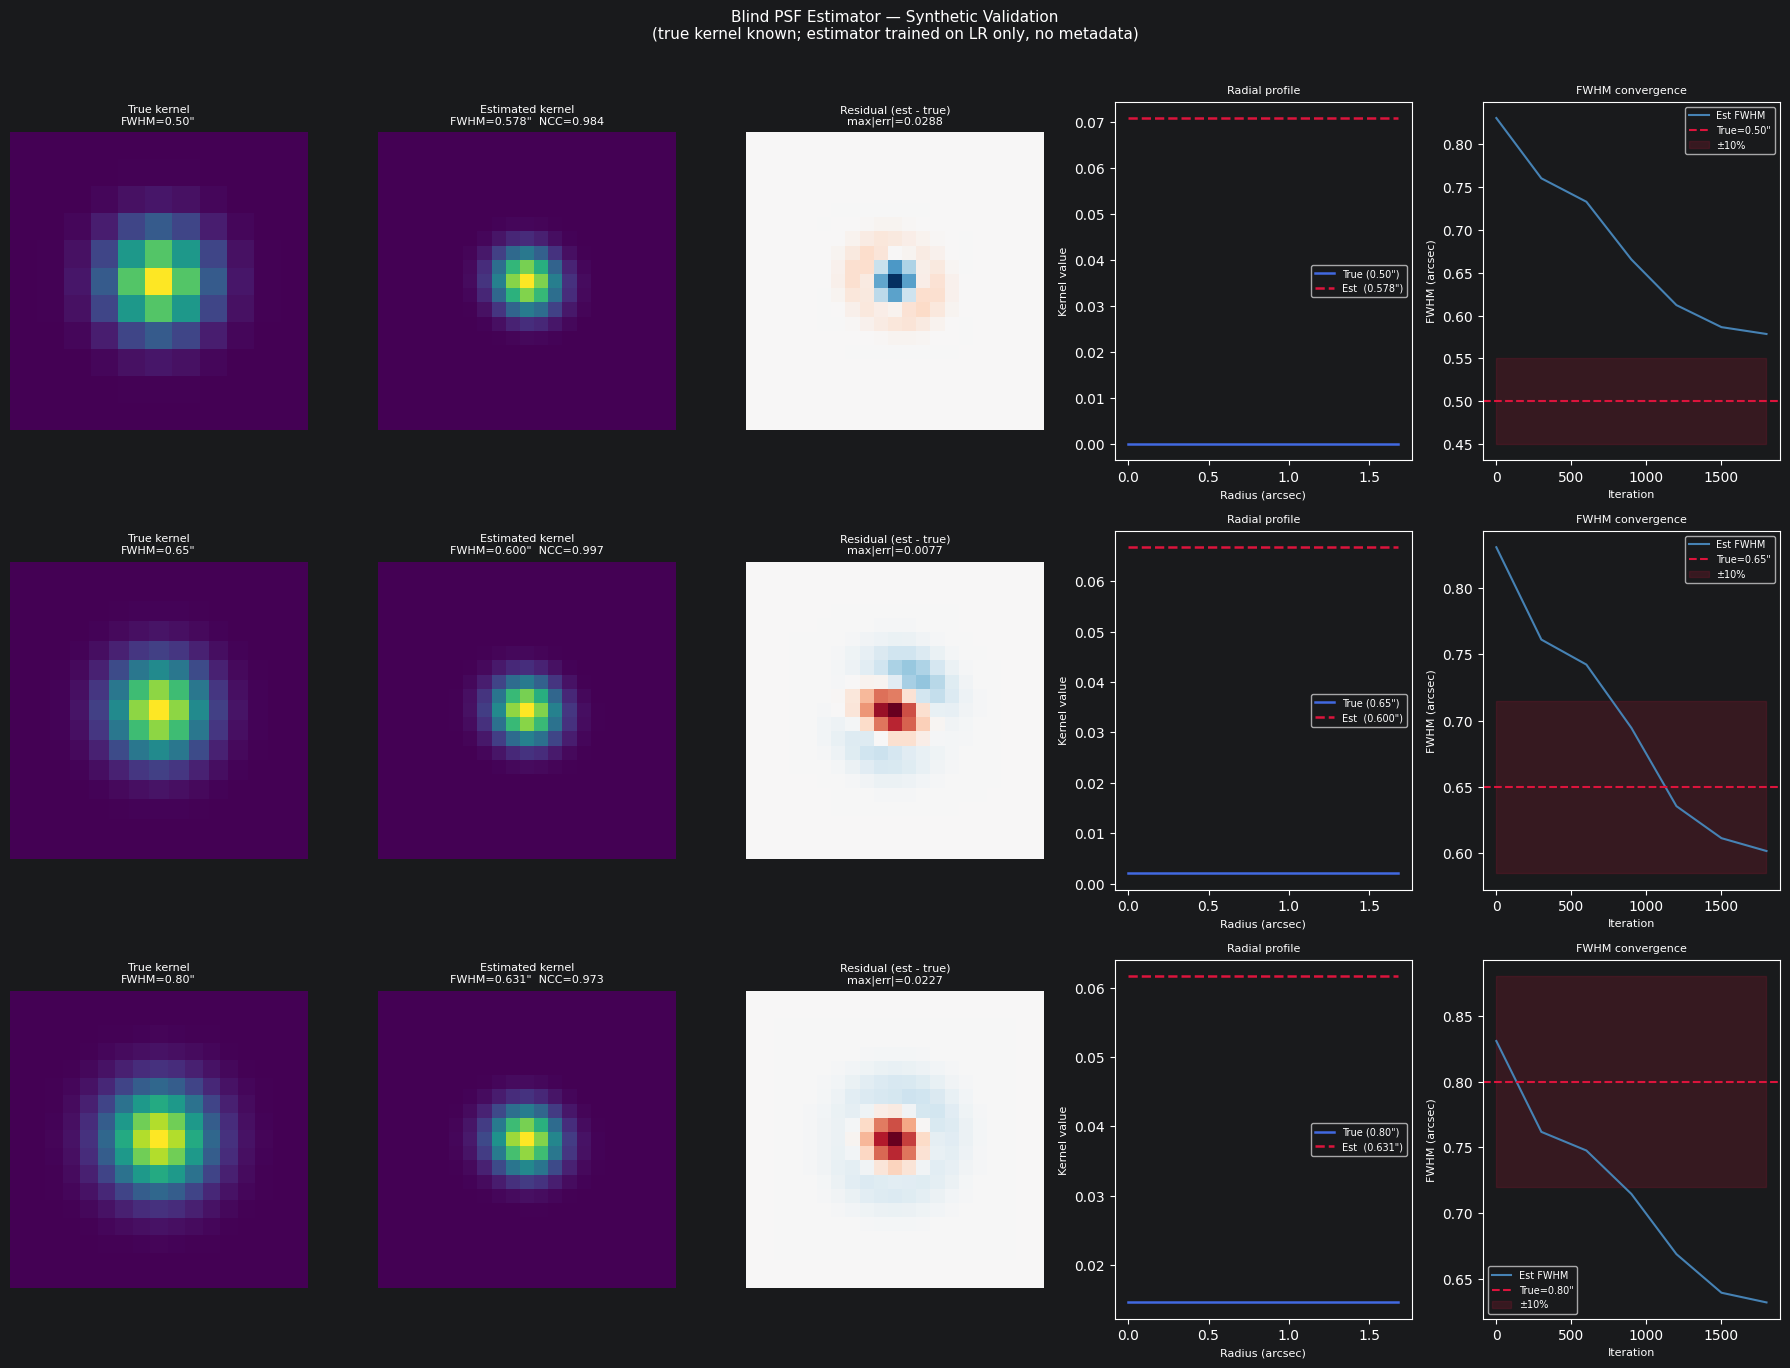


Synthetic validation summary:
   True FWHM   Est FWHM      Err     NCC   SSIM_est   SSIM_base
-----------------------------------------------------------------
      0.500"     0.578"   0.078"  0.9842     0.8111     0.8046
      0.650"     0.600"   0.050"  0.9969     0.8114     0.8059
      0.800"     0.631"   0.169"  0.9732     0.8081     0.8033


In [14]:
if not hr_images or not synthetic_results:
    print('No synthetic results to plot.')
else:
    import pandas as pd
    n_tests = len(synthetic_results)

    fig, axes = plt.subplots(n_tests, 5, figsize=(18, 4.5 * n_tests))
    if n_tests == 1:
        axes = axes[np.newaxis]  # ensure 2D

    for row, r in enumerate(synthetic_results):
        true_fwhm = r['true_fwhm_arcsec']
        est_fwhm  = r['est_fwhm_arcsec']
        ncc       = r['kernel_ncc']
        lh        = pd.DataFrame(r['loss_history'])

        # Col 0: true kernel
        ax = axes[row, 0]
        k  = r['true_kernel']
        ax.imshow(k, cmap='viridis', origin='lower', vmin=0)
        ax.set_title(f'True kernel\nFWHM={true_fwhm:.2f}"', fontsize=8)
        ax.axis('off')

        # Col 1: estimated kernel
        ax = axes[row, 1]
        k  = r['est_kernel']
        ax.imshow(k, cmap='viridis', origin='lower', vmin=0)
        ax.set_title(f'Estimated kernel\nFWHM={est_fwhm:.3f}"  NCC={ncc:.3f}', fontsize=8)
        ax.axis('off')

        # Col 2: residual
        ax  = axes[row, 2]
        # res = r['est_kernel'] - r['true_kernel']

        est_k = normalize_kernel(r["est_kernel"])
        true_k = normalize_kernel(r["true_kernel"])

        true_k = center_crop_or_pad(true_k, est_k.shape)

        res = est_k - true_k
        vext = np.abs(res).max()
        if vext == 0:
            vext = 1e-12

        ax.imshow(res, cmap="RdBu_r", origin="lower", vmin=-vext, vmax=vext)
        ax.set_title("Residual\nestimated - true")
        ax.axis("off")
        vext = np.abs(res).max()
        ax.imshow(res, cmap='RdBu_r', origin='lower', vmin=-vext, vmax=vext)
        ax.set_title(f'Residual (est - true)\nmax|err|={vext:.4f}', fontsize=8)
        ax.axis('off')

        # Col 3: radial profiles
        ax   = axes[row, 3]
        half = KERNEL_SIZE // 2
        radii_arcsec = np.arange(half + 1) * PIX_LR_ARCSEC
        for k_arr, label, color, ls in [
            (r['true_kernel'], f'True ({true_fwhm:.2f}")', 'royalblue', '-'),
            (r['est_kernel'],  f'Est  ({est_fwhm:.3f}")',  'crimson',   '--'),
        ]:
            # Radial max profile (simpler than azimuthal average, robust to off-centre peaks)
            prof = [k_arr[half, half:half+r_+1].max() if r_ > 0 else k_arr[half, half]
                    for r_ in range(half + 1)]
            ax.plot(radii_arcsec, prof, color=color, ls=ls, lw=1.8, label=label)
        ax.set_xlabel('Radius (arcsec)', fontsize=8)
        ax.set_ylabel('Kernel value', fontsize=8)
        ax.set_title('Radial profile', fontsize=8)
        ax.legend(fontsize=7)

        # Col 4: FWHM convergence over training
        ax = axes[row, 4]
        if len(lh) > 0:
            ax.plot(lh['iter'], lh['fwhm_arcsec'], color='steelblue', lw=1.5, label='Est FWHM')
            ax.axhline(true_fwhm, color='crimson', ls='--', lw=1.5, label=f'True={true_fwhm:.2f}"')
            ax.fill_between(lh['iter'], true_fwhm*0.9, true_fwhm*1.1,
                             alpha=0.15, color='crimson', label='±10%')
            ax.set_xlabel('Iteration', fontsize=8)
            ax.set_ylabel('FWHM (arcsec)', fontsize=8)
            ax.set_title('FWHM convergence', fontsize=8)
            ax.legend(fontsize=7)
        else:
            ax.text(0.5, 0.5, 'No log history', ha='center', va='center', transform=ax.transAxes)

    plt.suptitle('Blind PSF Estimator — Synthetic Validation\n'
                 '(true kernel known; estimator trained on LR only, no metadata)',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'synthetic_validation.png', dpi=130, bbox_inches='tight')
    plt.show()

    # Summary table
    print('\nSynthetic validation summary:')
    print(f'{"True FWHM":>12} {"Est FWHM":>10} {"Err":>8} {"NCC":>7} {"SSIM_est":>10} {"SSIM_base":>11}')
    print('-' * 65)
    for r in synthetic_results:
        print(f'{r["true_fwhm_arcsec"]:>11.3f}" '
              f'{r["est_fwhm_arcsec"]:>9.3f}" '
              f'{r["fwhm_err_arcsec"]:>7.3f}" '
              f'{r["kernel_ncc"]:>7.4f} '
              f'{r["deconv_ssim_est"]:>10.4f} '
              f'{r["deconv_ssim_base"]:>10.4f}')

## Cell 13 — Batch Run on Real LR Images (Blind, No Metadata)

Run the estimator on all available LR images. No ground truth needed.
Output: one `.npy` kernel file per image, ready to feed into the SR model.

In [ ]:
batch_results = []

print(f'Running blind PSF estimation on {len(lr_images)} LR images ...')
print(f'({N_ITERS} iterations each)\n')

for img_id, lr_img in lr_images.items():

    res = train_blind_psf(
        lr_image     = lr_img,
        n_iters      = N_ITERS,
        verbose      = False,
        log_interval = N_ITERS,   # only log final state
    )

    kernel     = res['kernel']
    # Save raw sum for debugging
    # raw_sum = float(np.nan_to_num(kernel).sum())
    kernel_raw = res["kernel_raw"]
    # Normalize before saving / downstream use
    # kernel = np.clip(kernel, 0.0, None)
    # kernel = kernel / (kernel.sum() + 1e-12)
    fwhm_r     = res['fwhm_result']

    # Save estimated kernel alongside LR image
    kernel_path = OUT_DIR / f'psf_kernel_{img_id}.npy'
    np.save(kernel_path, kernel)

    # If HR available: compute deconvolution SSIM as quality proxy
    deconv_ssim = None
    if img_id in hr_images:
        deconv_ssim = compute_deconv_ssim(lr_img, hr_images[img_id], kernel)

    row = {
        'image_id'         : img_id,
        'fwhm_px'          : round(fwhm_r['fwhm_px'],            3),
        'fwhm_arcsec'      : round(fwhm_r['fwhm_arcsec'],        3),
        'centroid_offset'  : round(fwhm_r['centroid_offset_px'], 3),
        # 'kernel_raw_sum'    : round(raw_sum, 6),
        'kernel_raw_sum'    : round(float(kernel_raw.sum()), 6),
        'kernel_sum'       : round(float(kernel.sum()),           6),
        'kernel_min'       : round(float(kernel.min()),           5),
        'deconv_ssim'      : round(deconv_ssim, 4) if deconv_ssim is not None else None,
    }
    batch_results.append(row)

    print(f'  {img_id}: FWHM={fwhm_r["fwhm_arcsec"]:.3f}"  '
          f'centroid_off={fwhm_r["centroid_offset_px"]:.2f}px  '
          f'k_sum={kernel.sum():.6f}  '
          f'k_min={kernel.min():.4f}'
          + (f'  SSIM={deconv_ssim:.4f}' if deconv_ssim else ''))


import pandas as pd
batch_df = pd.DataFrame(batch_results)

print()
print('=' * 60)
print('BATCH SUMMARY')
print('=' * 60)
print(batch_df.to_string(index=False))
print()
print(f'FWHM range  : {batch_df["fwhm_arcsec"].min():.3f}" – {batch_df["fwhm_arcsec"].max():.3f}"')
print(f'FWHM std    : {batch_df["fwhm_arcsec"].std():.3f}"  '
      f'(non-zero std means estimator is image-dependent ✓)')
print(f'Kernel sum  : mean={batch_df["kernel_sum"].mean():.4f}  '
      f'(should be ~1.0 due to L_norm regularisation)')
print(f'Centroid off: mean={batch_df["centroid_offset"].mean():.3f}px  '
      f'(should be <1px for a centred PSF)')
if 'deconv_ssim' in batch_df and batch_df['deconv_ssim'].notna().any():
    print(f'Deconv SSIM : mean={batch_df["deconv_ssim"].mean():.4f}')

batch_df.to_csv(OUT_DIR / 'blind_psf_results.csv', index=False)
print(f'\nSaved: blind_psf_results.csv')
print(f'Kernels: {OUT_DIR}/psf_kernel_<id>.npy')

Running blind PSF estimation on 50 LR images ...
(2000 iterations each)

  sample1: FWHM=0.541"  centroid_off=0.02px  k_sum=1.000000  k_min=0.0000  SSIM=0.9563
  sample10: FWHM=0.583"  centroid_off=0.32px  k_sum=1.000000  k_min=0.0000  SSIM=0.9553
  sample11: FWHM=0.508"  centroid_off=0.12px  k_sum=1.000000  k_min=0.0000  SSIM=0.9353
  sample12: FWHM=0.564"  centroid_off=0.03px  k_sum=1.000000  k_min=0.0000  SSIM=0.9579
  sample13: FWHM=0.580"  centroid_off=0.09px  k_sum=1.000000  k_min=0.0000  SSIM=0.9481


## Cell 14 — Kernel Grid: All Estimated PSFs

In [ ]:
n_imgs   = len(batch_results)
n_cols   = min(5, n_imgs)
n_rows   = (n_imgs + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for i, row in enumerate(batch_results):
    ax  = axes[i // n_cols, i % n_cols]
    k   = np.load(OUT_DIR / f'psf_kernel_{row["image_id"]}.npy')
    im  = ax.imshow(k, cmap='viridis', origin='lower', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Overlay estimated FWHM circle
    cx = cy = KERNEL_SIZE // 2
    est_r = row['fwhm_px'] / 2.0
    ax.add_patch(plt.Circle((cx, cy), est_r, fill=False,
                             color='yellow', lw=1.2, ls='--', alpha=0.9))

    ax.set_title(f'ID={row["image_id"]}\n'
                 f'FWHM={row["fwhm_arcsec"]:.3f}"  Δcen={row["centroid_offset"]:.2f}px',
                 fontsize=8)
    ax.axis('off')

# Hide unused axes
for j in range(n_imgs, n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis('off')

plt.suptitle('Blind PSF Estimator — All Estimated Kernels\n'
             '(dashed circle = estimated FWHM/2 radius)', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'all_kernels_blind.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: all_kernels_blind.png')

## Cell 15 — Diagnostics: Is the Estimator Image-Dependent?

The most important sanity check: do different LR images give different PSF estimates?  
If all FWHM values cluster at the same value, the estimator is still collapsing.

Healthy output: FWHM spread ≥ 0.05", centroid offset < 1px, kernel sum ≈ 1.0.

In [ ]:
fwhm_vals = batch_df['fwhm_arcsec'].values
cen_vals  = batch_df['centroid_offset'].values
ksum_vals = batch_df['kernel_sum'].values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# FWHM distribution
ax = axes[0]
ax.hist(fwhm_vals, bins=max(3, len(fwhm_vals)//2), color='steelblue', edgecolor='white')
ax.axvline(fwhm_vals.mean(), color='crimson', ls='--', lw=1.5, label=f'mean={fwhm_vals.mean():.3f}"')
ax.set_xlabel('Estimated FWHM (arcsec)')
ax.set_ylabel('Count')
ax.set_title(f'FWHM distribution\nstd={fwhm_vals.std():.3f}"  (non-zero = image-dependent ✓)')
ax.legend(fontsize=8)

# Centroid offset distribution
ax = axes[1]
ax.bar(range(len(cen_vals)), cen_vals, color='darkorange', edgecolor='white')
ax.axhline(1.0, color='crimson', ls='--', lw=1.5, label='1px threshold')
ax.set_xlabel('Image index')
ax.set_ylabel('Centroid offset (px)')
ax.set_title('Kernel centroid offset\n(< 1px = kernel is well-centred ✓)')
ax.legend(fontsize=8)

# Kernel sum (should be ~1.0 due to L_norm)
ax = axes[2]
ax.bar(range(len(ksum_vals)), ksum_vals, color='seagreen', edgecolor='white')
ax.axhline(1.0, color='crimson', ls='--', lw=1.5, label='Target sum = 1.0')
ax.set_xlabel('Image index')
ax.set_ylabel('Kernel sum')
ax.set_title('Kernel sum (flux conservation)\n(≈1.0 = L_norm is working ✓)')
ax.legend(fontsize=8)

plt.suptitle('Blind PSF Estimator — Diagnostic Plots', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'diagnostics.png', dpi=130, bbox_inches='tight')
plt.show()

# Final health check
print('\n── Health Check ──')
print(f'FWHM std     : {fwhm_vals.std():.4f}"  '
      + ('✓ image-dependent' if fwhm_vals.std() > 0.03 else '✗ may still be collapsing — check SCALE_FACTOR'))
print(f'Mean cen off : {cen_vals.mean():.3f}px  '
      + ('✓ well-centred' if cen_vals.mean() < 1.0 else '✗ kernel drifted from centre — check init or training instability'))
print(f'Mean k_sum   : {ksum_vals.mean():.4f}  '
      + ('✓ flux-conserved' if abs(ksum_vals.mean() - 1.0) < 0.05 else '✗ kernel sum far from 1 — increase LAMBDA_NORM'))
neg_fraction = np.array([np.load(OUT_DIR / f'psf_kernel_{r["image_id"]}.npy').min()
                          for r in batch_results])
print(f'Max k_min    : {neg_fraction.max():.5f}  '
      + ('✓ non-negative' if neg_fraction.max() >= -0.001 else f'✗ negative values present — increase LAMBDA_NEG'))

## Cell 16 — Summary and Next Steps

In [ ]:
print('=' * 65)
print('BLIND PSF ESTIMATOR PROTOTYPE — SUMMARY')
print('=' * 65)
print()
print('Architecture:')
print(f'  Generator     : DeepLinear  {G_N_LAYERS}L × {G_KERNEL_SIZE}×{G_KERNEL_SIZE}'
      f'  ({(G_KERNEL_SIZE-1)*G_N_LAYERS+1}px effective support)')
print(f'  Discriminator : PatchGAN  {D_PATCH_SIZE}×{D_PATCH_SIZE} patches')
print(f'  Cross-scale   : s={SCALE_FACTOR}  '
      f'Real=downsample(LR,{SCALE_FACTOR})  Fake=downsample(G(LR),{SCALE_FACTOR})')
print(f'  Regularisation: L_neg (λ={LAMBDA_NEG}) + L_norm (λ={LAMBDA_NORM})  [prototype only]')
print()
print('Differences from previous version:')
print('  [FIXED] Cross-scale mechanism: discriminator now sees real=LR↓ vs fake=G(LR)↓')
print('  [FIXED] L_size removed: no hard floor on kernel size → GAN signal drives size freely')
print('  [FIXED] FWHM: moment-based (always valid) instead of Gaussian curve_fit on Moffat')
print('  [FIXED] No metadata dependency anywhere in the pipeline')
print()
print('Validation metrics (no metadata):')
print('  1. Kernel NCC vs known synthetic ground truth       (synthetic test)')
print('  2. Deconv SSIM vs HR oracle                        (HR used offline only)')
print('  3. FWHM spread across images                       (non-zero = image-dependent)')
print('  4. Kernel sum ≈ 1.0, min ≥ 0, centroid offset < 1px')
print()
print('Output files:')
print(f'  {OUT_DIR}/psf_kernel_<id>.npy    — per-image estimated kernel')
print(f'  {OUT_DIR}/blind_psf_results.csv  — FWHM, diagnostics per image')
print(f'  {OUT_DIR}/synthetic_validation.png')
print(f'  {OUT_DIR}/all_kernels_blind.png')
print(f'  {OUT_DIR}/diagnostics.png')
print()
print('Next Steps (full implementation):')
print('  1. Add L_shape (ellipticity prior) and L_size (soft HSC seeing bound)')
print('     → These require careful λ tuning. Prototype confirms GAN signal works first.')
print('  2. Integrate kernel → spatial embedding → PSF-conditioned SR model')
print('     → Feed estimated psf_kernel_<id>.npy to SR training as conditioning input')
print('  3. Ablation: SR SSIM with (a) fixed Gaussian, (b) blind estimated, (c) oracle kernel')
print('     → This is the Week 1-2 GSoC milestone evidence')
print('=' * 65)